In [1]:
!pip install requests beautifulsoup4 pandas matplotlib

In [59]:
!pip install scikit-learn requests beautifulsoup4 pandas matplotlib

In [60]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

# Training data (simple rule-based dataset)
X = np.array([
    [1],  # low impact
    [2],
    [3],
    [4],
    [5]   # high impact
])

y = ["Low", "Low", "Medium", "High", "Critical"]

model = DecisionTreeClassifier()
model.fit(X, y)


def predict_severity(score):
    return model.predict([[score]])[0]

In [62]:
!pip install scikit-learn requests beautifulsoup4 pandas matplotlib

In [63]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import urllib3

urllib3.disable_warnings()

In [69]:
class Vulnerability:

    def __init__(self,name,severity,url,description):

        self.name = name
        self.severity = severity
        self.url = url
        self.description = description

In [70]:
def check_security_headers(url):

    findings = []

    try:

        response = requests.get(url,verify=False)

        headers = response.headers

        required_headers = [
            "Content-Security-Policy",
            "X-Frame-Options",
            "Strict-Transport-Security",
            "X-Content-Type-Options"
        ]

        for header in required_headers:

            if header not in headers:

                severity = predict_severity(3)

                findings.append(
                    Vulnerability(
                        "Missing Security Header",
                        severity,
                        url,
                        f"{header} header missing"
                    )
                )

    except:
        print("Error accessing website")

    return findings

In [67]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 115.3 MB/s eta 0:00:00


In [71]:
def check_xss(url):

    findings = []

    payload = "<script>alert(1)</script>"

    try:

        test_url = url + "?q=" + payload

        response = requests.get(test_url,verify=False)

        if payload in response.text:

            severity = predict_severity(4)

            findings.append(
                Vulnerability(
                    "Possible XSS",
                    severity,
                    test_url,
                    "Input reflected in response"
                )
            )

    except:
        pass

    return findings

In [72]:
def check_sql_injection(url):

    findings = []

    payload = "' OR '1'='1"

    try:

        test_url = url + "?id=" + payload

        response = requests.get(test_url,verify=False)

        errors = ["sql","mysql","database"]

        for e in errors:

            if e in response.text.lower():

                severity = predict_severity(5)

                findings.append(
                    Vulnerability(
                        "Possible SQL Injection",
                        severity,
                        test_url,
                        "SQL error detected"
                    )
                )

                break

    except:
        pass

    return findings

In [73]:
def check_directory_listing(url):

    findings = []

    dirs = ["/uploads/","/images/","/backup/"]

    for d in dirs:

        try:

            test_url = url + d

            response = requests.get(test_url,verify=False)

            if "Index of" in response.text:

                severity = predict_severity(3)

                findings.append(
                    Vulnerability(
                        "Directory Listing",
                        severity,
                        test_url,
                        "Directory listing enabled"
                    )
                )

        except:
            pass

    return findings

In [74]:
def check_open_redirect(url):

    findings = []

    payload = "https://google.com"

    try:

        test_url = url + "?redirect=" + payload

        response = requests.get(test_url,allow_redirects=False,verify=False)

        if "Location" in response.headers:

            if payload in response.headers["Location"]:

                severity = predict_severity(2)

                findings.append(
                    Vulnerability(
                        "Open Redirect",
                        severity,
                        test_url,
                        "Redirect parameter not validated"
                    )
                )

    except:
        pass

    return findings

In [75]:
def run_scan(url):

    findings = []

    findings += check_security_headers(url)
    findings += check_xss(url)
    findings += check_sql_injection(url)
    findings += check_directory_listing(url)
    findings += check_open_redirect(url)

    return findings

In [76]:
target_url = input("Enter website URL: ")

results = run_scan(target_url)

print("\nScan Results\n")

for r in results:

    print("Vulnerability:",r.name)
    print("Severity:",r.severity)
    print("URL:",r.url)
    print("Description:",r.description)
    print("-----------------------")

Enter website URL: http://example.com

Scan Results

Vulnerability: Missing Security Header
Severity: Medium
URL: http://example.com
Description: Content-Security-Policy header missing
-----------------------
Vulnerability: Missing Security Header
Severity: Medium
URL: http://example.com
Description: X-Frame-Options header missing
-----------------------
Vulnerability: Missing Security Header
Severity: Medium
URL: http://example.com
Description: Strict-Transport-Security header missing
-----------------------
Vulnerability: Missing Security Header
Severity: Medium
URL: http://example.com
Description: X-Content-Type-Options header missing
-----------------------


In [77]:
data = []

for r in results:

    data.append({
        "Vulnerability": r.name,
        "Severity": r.severity,
        "URL": r.url,
        "Description": r.description
    })

df = pd.DataFrame(data)

df

,Vulnerability,Severity,URL,Description
0,Missing Security Header,Medium,http://example.com,Content-Security-Policy header missing
1,Missing Security Header,Medium,http://example.com,X-Frame-Options header missing
2,Missing Security Header,Medium,http://example.com,Strict-Transport-Security header missing
3,Missing Security Header,Medium,http://example.com,X-Content-Type-Options header missing


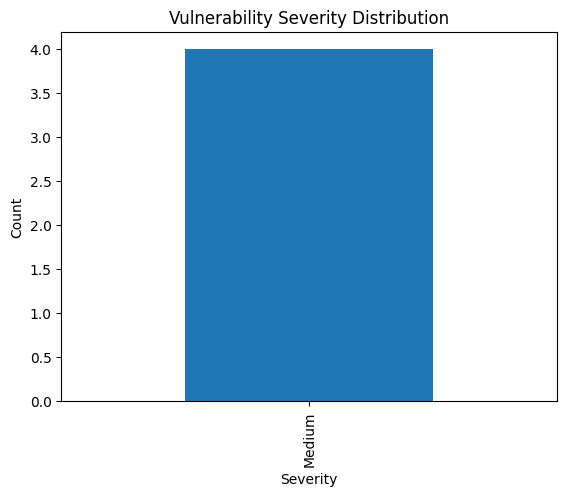

In [78]:
severity_counts = df["Severity"].value_counts()

severity_counts.plot(kind="bar")

plt.title("Vulnerability Severity Distribution")

plt.xlabel("Severity")

plt.ylabel("Count")

plt.show()

In [79]:
import smtplib
from email.mime.text import MIMEText
from getpass import getpass

def send_email_alert(url, findings):

    high_findings = [f for f in findings if f.severity in ["High","Critical"]]

    if len(high_findings) == 0:
        print("No High severity vulnerabilities found")
        return

    email = input("Enter Gmail: ")
    password = getpass("Enter App Password: ")

    message = f"High severity vulnerabilities detected on {url}\n\n"

    for f in high_findings:
        message += f"{f.name} - {f.severity}\n"

    msg = MIMEText(message)

    msg["Subject"] = "Web Vulnerability Alert"
    msg["From"] = email
    msg["To"] = email

    server = smtplib.SMTP("smtp.gmail.com",587)
    server.starttls()

    server.login(email,password)

    server.send_message(msg)

    server.quit()

    print("Email alert sent!")

In [81]:
results.append(
    Vulnerability(
        "Test Vulnerability",
        "High",
        target_url,
        "Testing email alert system"
    )
)

In [82]:
send_email_alert(target_url, results)

Enter Gmail: paidimarrysuma@gmail.com
Enter App Password: ··········
Email alert sent!
